1. Write a python program to demonstrate on Fourier, transform inverse Fourier Transform of an
image

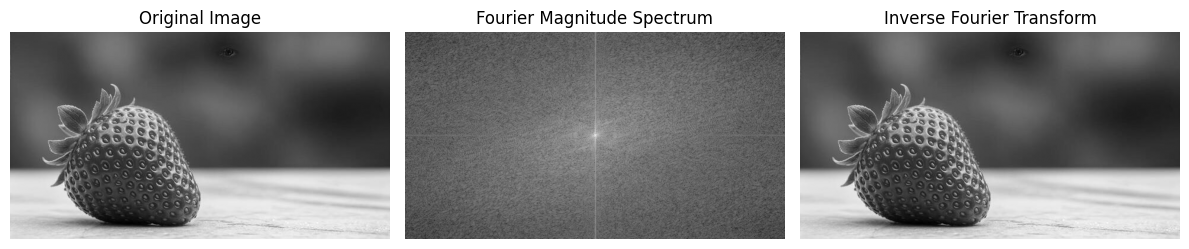

In [4]:
import cv2 
import numpy as np 
import matplotlib.pyplot as plt 
# 1. Load the image in grayscale 
image=cv2.imread('image.jpg',cv2.IMREAD_GRAYSCALE) 
if image is None: 
    raise FileNotFoundError("Check image path.") 
# 2. Forward Fourier Transform (FT) 
# Compute the 2D Fast Fourier Transform 
f_transform = np.fft.fft2(image) 
# Shift the zero-frequency (DC) component to the center of the spectrum 
f_shift = np.fft.fftshift(f_transform) 
# Calculate the magnitude spectrum (log scale for visualization) 
magnitude_spectrum = 20 * np.log(np.abs(f_shift) + 1) 
# 3. Inverse Fourier Transform (IFT) 
# Shift back the zero-frequency component to its original position 
f_ishift = np.fft.ifftshift(f_shift) 
# Compute the Inverse 2D Fast Fourier Transform 
img_back = np.fft.ifft2(f_ishift) 
# Take the real part of the complex result 
img_back = np.abs(img_back) 
# 4. Visualization 
plt.figure(figsize=(12, 6)) 
plt.subplot(131), plt.imshow(image, cmap='gray') 
plt.title('Original Image'), plt.axis('off') 
plt.subplot(132), plt.imshow(magnitude_spectrum, cmap='gray') 
plt.title('Fourier Magnitude Spectrum'), plt.axis('off') 
plt.subplot(133), plt.imshow(img_back, cmap='gray') 
plt.title('Inverse Fourier Transform'), plt.axis('off') 
plt.tight_layout() 
plt.show() 

2. Write a python program to demonstrate on different Frequency domain filtering techniques
on an image by applying ideal, Butterworth and Gaussian low pass filters and high pass filters.

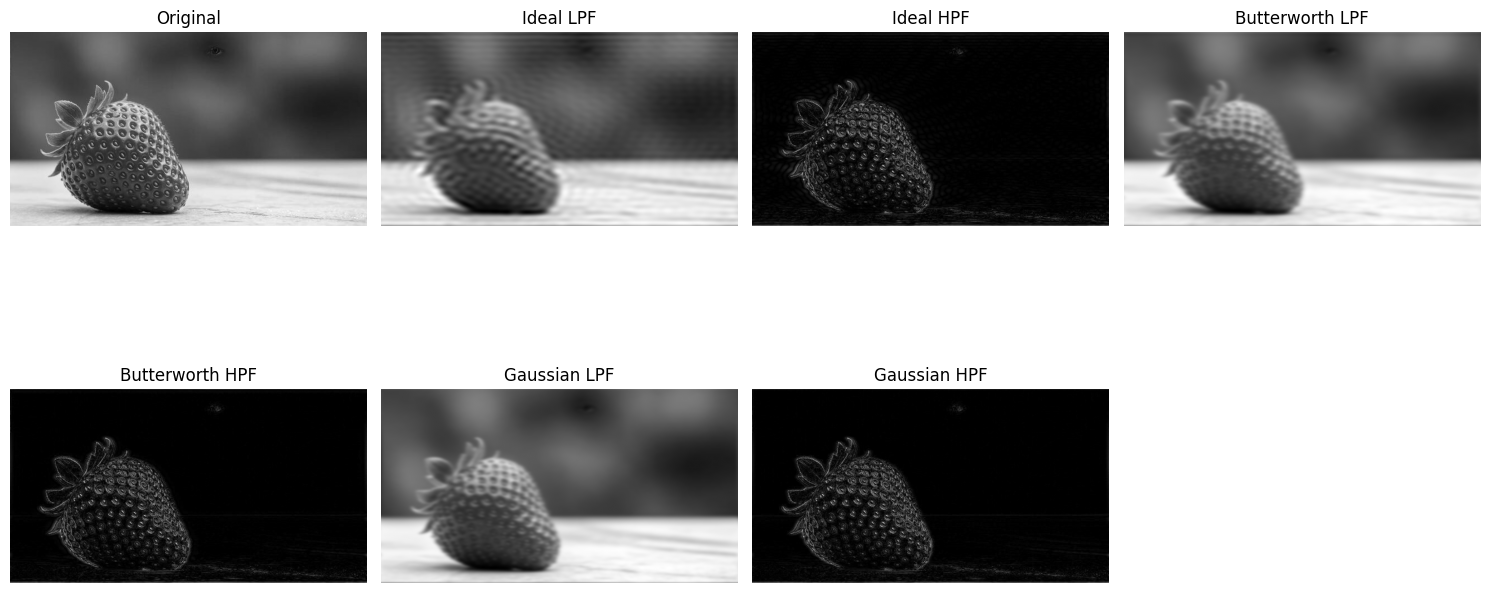

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# ── Load & prep ──────────────────────────────────────────────
img = cv2.imread('image.jpg', cv2.IMREAD_GRAYSCALE)
rows, cols = img.shape
cx, cy = rows // 2, cols // 2          # center

# FFT
F = np.fft.fftshift(np.fft.fft2(img))

# ── Distance map (same size as image) ────────────────────────
x = np.arange(cols) - cy
y = np.arange(rows) - cx
X, Y = np.meshgrid(x, y)
D = np.sqrt(X**2 + Y**2)              # distance from center

# ── Filter factory ───────────────────────────────────────────
D0, n = 30, 2                          # cutoff, butterworth order

filters = {
    'Ideal LPF'      : (D <= D0).astype(float),
    'Ideal HPF'      : (D >  D0).astype(float),
    'Butterworth LPF': 1 / (1 + (D / D0)**(2*n)),
    'Butterworth HPF': 1 / (1 + (D0 / (D + 1e-6))**(2*n)),
    'Gaussian LPF'   : np.exp(-D**2 / (2 * D0**2)),
    'Gaussian HPF'   : 1 - np.exp(-D**2 / (2 * D0**2)),
}

# ── Apply & show ─────────────────────────────────────────────
plt.figure(figsize=(15, 8))

plt.subplot(2, 4, 1)
plt.imshow(img, cmap='gray')
plt.title('Original'), plt.axis('off')

for i, (name, mask) in enumerate(filters.items(), start=2):
    filtered = np.abs(np.fft.ifft2(np.fft.ifftshift(F * mask)))
    plt.subplot(2, 4, i)
    plt.imshow(filtered, cmap='gray')
    plt.title(name), plt.axis('off')

plt.tight_layout()
plt.show()

3. Write a python program to demonstrate on Hit or Miss Transform

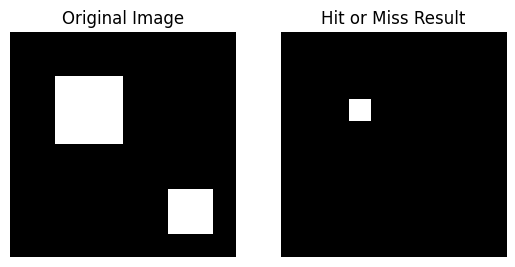

In [2]:
import numpy as np 
from scipy.ndimage import binary_hit_or_miss 
import matplotlib.pyplot as plt 
# 1. Create a sample binary image 
image = np.zeros((10, 10), dtype=int) 
image[2:5, 2:5] = 1 
image[7:9, 7:9] = 1 # Second shape to find 
# 2. Define the kernel (Hit-or-Miss Template) 
# Structure: 1 for hit (foreground), 0 for miss (background) 
# This looks for a 3x3 square pattern 
kernel = np.array([[1, 1, 1], 
[1, 1, 1], 
[1, 1, 1]]) 
# 3. Apply the hit-or-miss transform 
result = binary_hit_or_miss(image, structure1=kernel) 
# 4. Display the results 
plt.subplot(121) 
plt.imshow(image, cmap='gray') 
plt.title('Original Image'), plt.axis('off')
plt.subplot(122) 
plt.imshow(result, cmap='gray') 
plt.title('Hit or Miss Result'), plt.axis('off')
plt.show()

4. Implement the Canny Edge Detector algorithm, including Gaussian blurring, gradient
calculation, non-maximum suppression, and double thresholding. (No inbuilt function) to be
used for canny edge detection

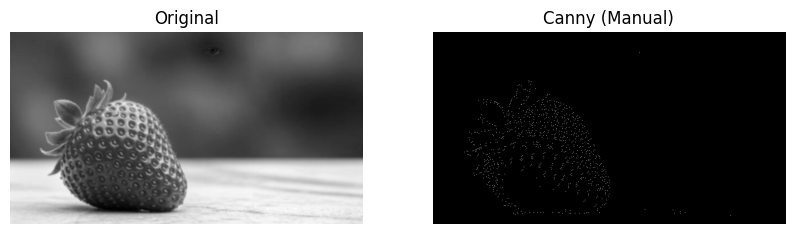

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter

img = cv2.imread('image.jpg', 0)

# 1. Blur
img = cv2.GaussianBlur(img, (5,5), 1)

# 2. Gradient magnitude
gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
mag = np.sqrt(gx**2 + gy**2)
mag = (mag / mag.max()) * 255

# 3. Non-max suppression → keep pixel only if it's the local max in a 3x3 window
nms = np.where(mag == maximum_filter(mag, size=3), mag, 0)

# 4. Double threshold
low, high = 30, 80
edges = np.zeros_like(nms)
edges[nms >= high] = 255          # strong
edges[(nms >= low) & (nms < high)] = 75   # weak

# 5. Hysteresis → weak pixel survives if any neighbor is strong
strong_neighbors = maximum_filter(edges == 255, size=3)
edges[(edges == 75) & ~strong_neighbors] = 0
edges[edges == 75] = 255

# Display
plt.figure(figsize=(10,5))
plt.subplot(121), plt.imshow(img, cmap='gray'), plt.title("Original"), plt.axis('off')
plt.subplot(122), plt.imshow(edges, cmap='gray'), plt.title("Canny (Manual)"), plt.axis('off')
plt.show()

5. Implement region-based segmentation in Python using Region Growing

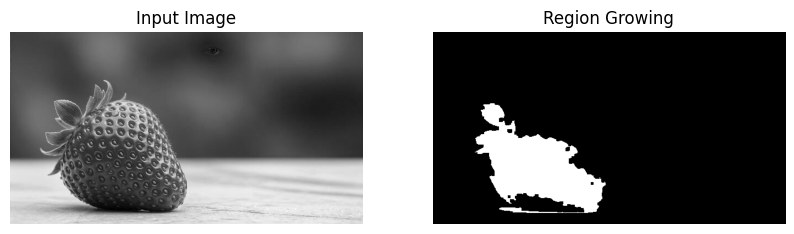

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
def region_growing(img, seed, threshold):
    """
    Simple 4-connected region growing implementation.
    """
    rows, cols = img.shape
    segmented = np.zeros((rows, cols), dtype=np.uint8)
    visited = np.zeros((rows, cols), dtype=bool)
    stack = [seed]
    seed_value = int(img[seed])
    visited[seed] = True
    while stack:
        y, x = stack.pop()
        segmented[y, x] = 255
        # 4-connected neighbors
        for ny, nx in [(y-1, x), (y+1, x), (y, x-1), (y, x+1)]:
            if 0 <= ny < rows and 0 <= nx < cols and not visited[ny, nx]:
                if abs(int(img[ny, nx]) - seed_value) <= threshold:
                    visited[ny, nx] = True
                    stack.append((ny, nx))
    return segmented
# --- Usage --
image = cv2.imread('image.jpg', cv2.IMREAD_GRAYSCALE)
# Seed point (choose a point inside object)
seed_point = (200, 200)
# Threshold controls growth sensitivity
threshold = 30
result = region_growing(image, seed_point, threshold)
kernel = np.ones((5,5), np.uint8)
result = cv2.morphologyEx(result, cv2.MORPH_CLOSE, kernel)
# Display
plt.figure(figsize=(10,5))
plt.subplot(121)
plt.imshow(image, cmap='gray')
plt.title('Input Image')
plt.axis('off')
plt.subplot(122)
plt.imshow(result, cmap='gray')
plt.title('Region Growing')
plt.axis('off')
plt.show()


6. Write a python program to implement Region segmentation using watersheds

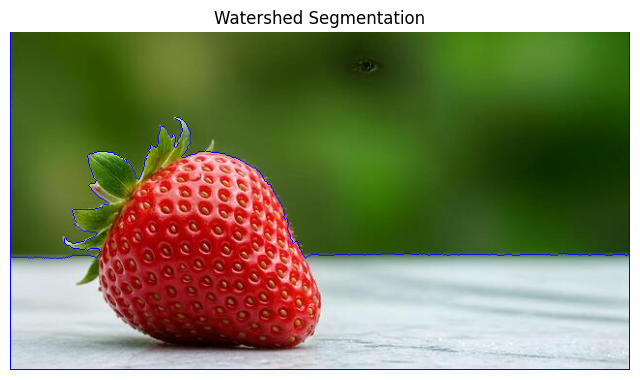

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
def watershed_segmentation(image_path):
    """
    Performs morphological watershed segmentation on an image.
    """
    # 1. Load image
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # 2. Otsu Thresholding
    _, thresh = cv2.threshold(gray, 0, 255,
                              cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    # 3. Noise removal (Opening)
    kernel = np.ones((3, 3), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
    # 4. Sure background (dilation)
    sure_bg = cv2.dilate(opening, kernel, iterations=3)
    # 5. Distance transform (for foreground)
    dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    _, sure_fg = cv2.threshold(dist_transform,
                               0.7 * dist_transform.max(),
                               255, 0)
    # Convert to uint8
    sure_fg = np.uint8(sure_fg)
    # 6. Unknown region
    unknown = cv2.subtract(sure_bg, sure_fg)
    # 7. Marker labeling
    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1  # Background becomes 1
    markers[unknown == 255] = 0  # Unknown = 0
    # 8. Apply Watershed
    markers = cv2.watershed(img, markers)
    # Mark boundaries in red
    img[markers == -1] = [255, 0, 0]
    # 9. Display
    plt.figure(figsize=(8,6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Watershed Segmentation")
    plt.axis('off')
    plt.show()
# --- Main --
if __name__ == "__main__":
    watershed_segmentation('image.jpg')   # change path if needed
